FINTECH CHURN INTELLIGENCE

Exploratory Data Analysis (EDA)

Objective

This notebook explores customer churn patterns across demographic,
financial and behavioral variables.

Key goals:

- Understand overall churn distribution
- Identify high-risk customer segments
- Analyze churn by geography, age, gender and products
- Explore customer activity and balance patterns
- Generate business insights for retention strategy

Business Question

Why are customers leaving the fintech platform and which customer
segments contribute most to churn?

In [3]:
import pandas as pd

df = pd.read_csv('../01_Data/Churn_Modelling.csv')

print(df.shape)

df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10000
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)
print(df.columns)
df.head()

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
churn_rate = round(df['Exited'].mean()*100,2)
print("Churn Rate:", churn_rate,"%")

Churn Rate: 20.37 %


Insight:
The company churn rate is 20.37%.
Out of 10,000 customers,2,037 customers left the company.
This churn rate is significantly high and indicates a customer retention problem.

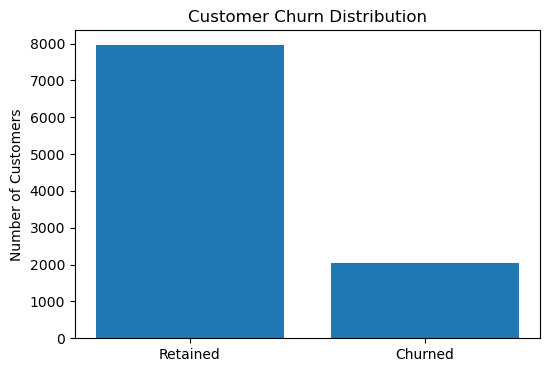

In [8]:
import matplotlib.pyplot as plt
churn_counts = df['Exited'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(
    ['Retained','Churned'],
    churn_counts.values)
plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')

plt.show()

In [9]:
geo_churn = df.groupby('Geography')['Exited'].agg(
    total_customers='count',
    churned_customers='sum',
    churn_rate='mean')

geo_churn['churn_rate'] = round(
    geo_churn['churn_rate'] * 100,2)

geo_churn.sort_values(
    by='churn_rate',
    ascending=False)

,total_customers,churned_customers,churn_rate
Geography,,,
Germany,2509,814,32.44
Spain,2477,413,16.67
France,5014,810,16.15


Insight:
Germany has the highest churn rate among all regions.
Although Germany does not have the largest customer base, it contributes a disproportionately high number of churned customers.
This indicates a geography-specific retention issue that should be investigated further.

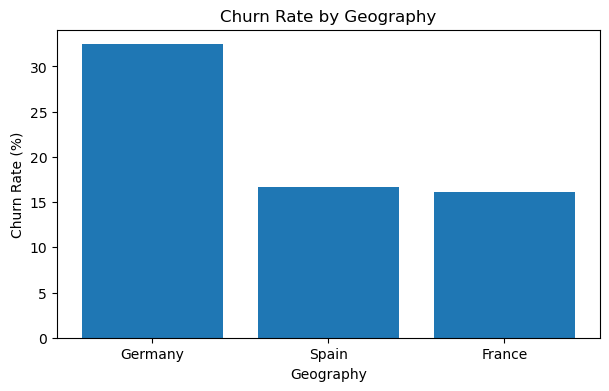

In [10]:
geo_churn = geo_churn.sort_values(
    by='churn_rate',
    ascending=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.bar(
    geo_churn.index,
    geo_churn['churn_rate'])
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Geography")
plt.show()

In [11]:
age_churn = df.groupby('Age')['Exited'].mean()*100
age_churn.head()

Age
18     9.090909
19     3.703704
20     5.000000
21     5.660377
22    14.285714
Name: Exited, dtype: float64

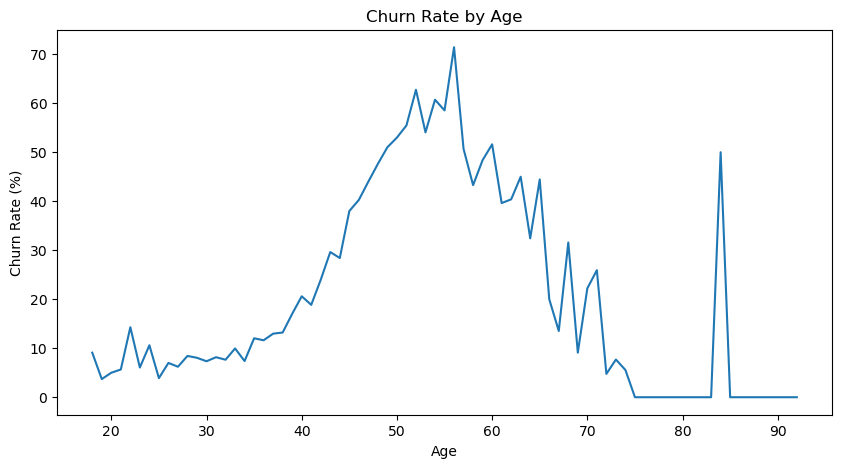

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    age_churn.index,
    age_churn.values
)

plt.title('Churn Rate by Age')
plt.xlabel('Age')
plt.ylabel('Churn Rate (%)')

plt.show()

In [13]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

age_group_churn = df.groupby('Age_Group')['Exited'].mean()*100

round(age_group_churn,2)

/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_35754/376491511.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_churn = df.groupby('Age_Group')['Exited'].mean()*100


Age_Group
18-30     7.50
31-40    12.09
41-50    33.97
51-60    56.21
60+      24.78
Name: Exited, dtype: float64

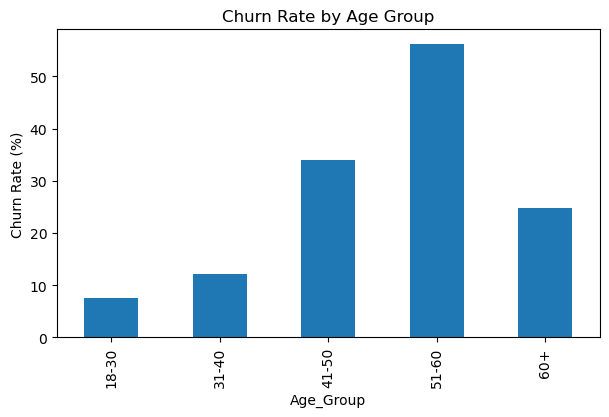

In [14]:
age_group_churn.plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate (%)')

plt.show()

Insight:
Churn increases significantly with age.
Customers above 50 years old show the highest churn rates.
Older customers should be considered a high-risk retention segment and targeted with personalized retention programs.

In [15]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean()*100

round(product_churn,2)

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

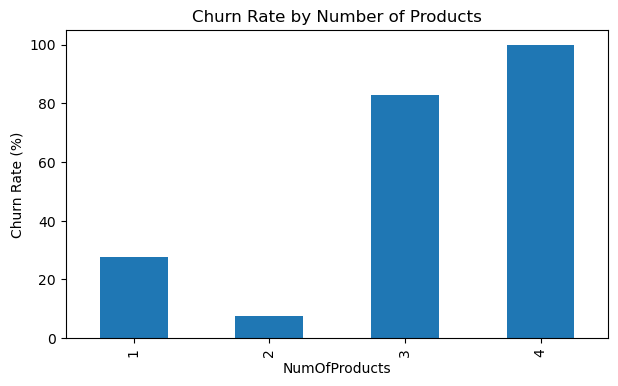

In [16]:
product_churn.plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate (%)')

plt.show()

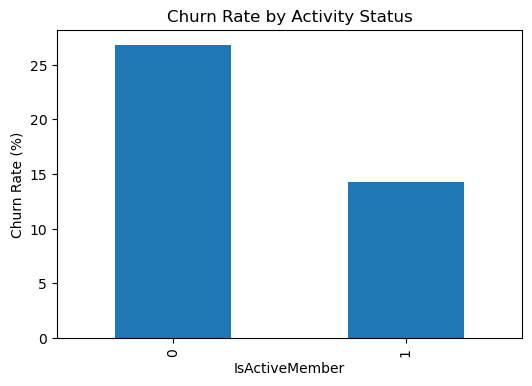

In [19]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean()*100
round(active_churn,2)
active_churn.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Activity Status')
plt.ylabel('Churn Rate (%)')

plt.show()

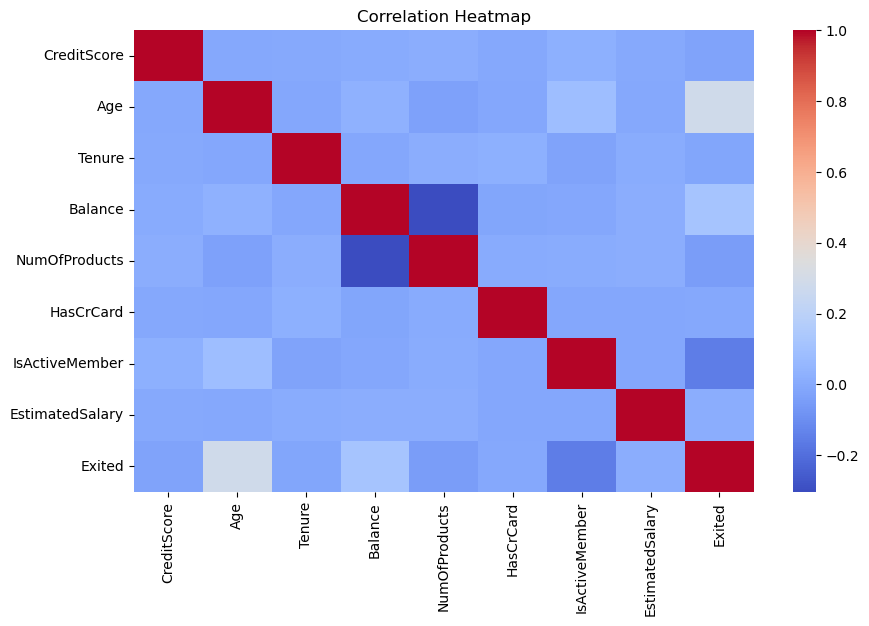

In [21]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()